In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("/content/placement.csv")

In [4]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df.shape

(100, 4)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [8]:
np.unique(df['cgpa'])

array([3.3, 3.5, 3.9, 4. , 4.3, 4.4, 4.6, 4.7, 4.8, 4.9, 5. , 5.1, 5.2,
       5.3, 5.4, 5.7, 5.8, 5.9, 6. , 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7,
       6.8, 6.9, 7. , 7.1, 7.3, 7.4, 7.5, 7.6, 7.8, 8. , 8.1, 8.3, 8.5])

In [9]:
df = df.iloc[:,1:]

In [10]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [11]:
import matplotlib.pyplot as plt

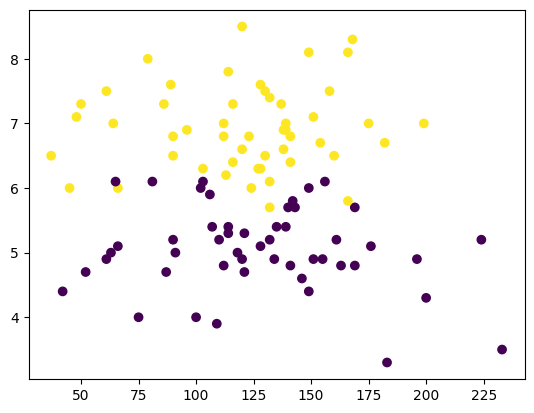

In [13]:
plt.scatter(df['iq'],df['cgpa'], c=df['placement'])


In [17]:
x = df.drop('placement',axis=1)
y = df['placement']

In [18]:
x.head()

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [16]:
from sklearn.model_selection import train_test_split

In [30]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)

In [31]:
x_train

,cgpa,iq
80,4.9,196.0
97,6.7,182.0
56,6.1,65.0
46,5.3,114.0
31,3.9,109.0
...,...,...
49,5.4,135.0
13,6.4,116.0
22,4.9,120.0
30,7.6,128.0


In [22]:
from sklearn.preprocessing import StandardScaler

In [32]:
x_test

,cgpa,iq
12,5.4,139.0
27,6.0,124.0
82,6.5,37.0
1,5.9,106.0
14,6.1,103.0
15,5.1,176.0
38,6.5,160.0
78,6.1,81.0
60,6.9,139.0
58,8.0,79.0


In [33]:
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
clf = LogisticRegression()

In [36]:
clf.fit(x_train,y_train)

LogisticRegression()

In [38]:
y_pred = clf.predict(x_test)

In [39]:
from sklearn.metrics import accuracy_score

In [40]:
accuracy_score(y_test, y_pred)

0.8

In [41]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

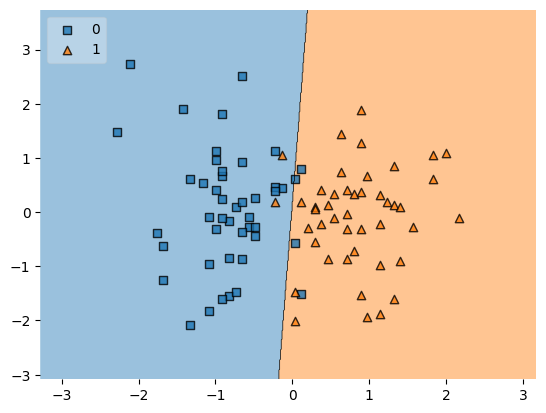

In [42]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [43]:
import pickle

In [45]:
pickle.dump(clf,open('model.pkl','wb'))